In [176]:
!pip install mesa[rec]

In [177]:
!pip install seaborn


In [178]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [179]:
import random
from mesa.datacollection import DataCollector
import matplotlib.pyplot as plt

class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, trader_type):
        # Pass the parameters to the parent class.
        super().__init__(model)

        self.trader_type = trader_type  # "technical", "fundamental", "noise"
        self.cash = 1000  # Başlangıç nakit miktarı
        self.shares = 10  # Başlangıç hisse sayısı
        self.history_window = random.randint(14, 200)  # Geçmiş veri penceresi

        self.al_sayisi = 0
        self.sat_sayisi = 0


    def step(self):
        """ Ajanın her adımda yapacağı işlem """

        market_trend = self.analyze_market()

        if self.trader_type == "technical":
            self.technical_trading(market_trend)
            print(f"ID: {self.unique_id}")
            print(f"Trader Type: {self.trader_type}")
            print(f"Cash: {self.cash}")
            print(f"Shares: {self.shares}")


        elif self.trader_type == "fundamental":
            self.fundamental_trading(market_trend)
            print(f"ID: {self.unique_id}")
            print(f"Trader Type: {self.trader_type}")
            print(f"Cash: {self.cash}")
            print(f"Shares: {self.shares}")


        elif self.trader_type == "noise":
            self.noise_trading()
            print(f"ID: {self.unique_id}")
            print(f"Trader Type: {self.trader_type}")
            print(f"Cash: {self.cash}")
            print(f"Shares: {self.shares}")

        #print(f"döngü: {self.sayac}") #self.sayac is not defined

    def analyze_market(self):
        """ Piyasanın boğa, ayı veya aralık piyasası olduğunu belirle """
        if len(self.model.price_history) < self.history_window:
            return "unknown"  # Yeterli veri yoksa belirleme yapma

        recent_prices = self.model.price_history[-self.history_window:]
        price_changes = np.diff(recent_prices)

        if np.all(price_changes > 0):
            return "bull"  # Boğa piyasası
        elif np.all(price_changes < 0):
            return "bear"  # Ayı piyasası
        else:
            return "range"  # Aralık piyasası

    def technical_trading(self, market_trend):
        """ Teknik analiz bazlı alım-satım """
        if market_trend == "bull":
            self.buy_stock()
            self.al_sayisi += 1
            print(f"Alım Sayısı: {self.al_sayisi}")
        elif market_trend == "bear":
            self.sell_stock()
            self.sat_sayisi += 1
            print(f"Satım Sayısı: {self.sat_sayisi}")
        else:
            if random.random() < 0.5:
                self.buy_stock()
                self.al_sayisi += 1
                print(f"Alım Sayısı: {self.al_sayisi}")
            else:
                self.sell_stock()
                self.sat_sayisi += 1
                print(f"Satım Sayısı: {self.sat_sayisi}")

    def fundamental_trading(self, market_trend):
        """ Temel analiz bazlı alım-satım """
        if market_trend == "bull":
            self.buy_stock()
            self.al_sayisi += 1
            print(f"Alım Sayısı: {self.al_sayisi}")
        elif market_trend == "bear":
            self.sell_stock()
            self.sat_sayisi += 1
            print(f"Satım Sayısı: {self.sat_sayisi}")
        else:
            if random.random() < 0.6:
                self.buy_stock()
                self.al_sayisi += 1
                print(f"Alım Sayısı: {self.al_sayisi}")
            else:
                self.sell_stock()
                self.sat_sayisi += 1
                print(f"Satım Sayısı: {self.sat_sayisi}")



    def noise_trading(self):
        """ Gürültü yatırımcılarının rastgele işlemleri """
        if random.random() < 0.5:
            self.buy_stock()
            self.al_sayisi += 1
            print(f"Alım Sayısı: {self.al_sayisi}")
        else:
            self.sell_stock()
            self.sat_sayisi += 1
            print(f"Satım Sayısı: {self.sat_sayisi}")

    def buy_stock(self):
        """ Hisse senedi satın alma """
        if self.cash >= self.model.stock_price:
            self.cash -= self.model.stock_price
            self.shares += 1

    def sell_stock(self):
        """ Hisse senedi satma """
        if self.shares > 0:
            self.cash += self.model.stock_price
            self.shares -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, tech_ratio=0.4, fund_ratio=0.4, noise_ratio=0.2, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        #self.stock_price = 100  # Başlangıç hisse fiyatı
        self.sayac = 0

        # 300 günlük geçmiş fiyat serisi oluştur (rastgele yürüyüş)
        self.price_history = [100]  # İlk değer
        for _ in range(299):
            self.price_history.append(self.price_history[-1] + random.uniform(-1, 1))

        self.stock_price = self.price_history[-1]  # Son değeri başlangıç fiyatı olarak al


        # Ajan sayılarını belirleme
        num_technical = int(self.num_agents * tech_ratio)
        num_fundamental = int(self.num_agents * fund_ratio)
        num_noise = self.num_agents - (num_technical + num_fundamental)  # Geriye kalanlar noise olur

        # Ajanları oluştur ve modele ekle
        for i in range(num_technical):
            agent = MoneyAgent(self, "technical")
            self.agents.add(agent)
        for i in range(num_fundamental):
            agent = MoneyAgent(self, "fundamental")
            self.agents.add(agent)
        for i in range(num_noise):
            agent = MoneyAgent(self, "noise")
            self.agents.add(agent)


        # DataCollector'ı ayarla
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Price": lambda m: m.stock_price,  # Güncel fiyat
                "Price_History": lambda m: m.price_history.copy()  # Tüm fiyat geçmişi
            },
            agent_reporters={"Nakit": "cash"}  # Ajan seviyesinde veri

        )

    def step(self):
        """ Modelin her adımda çalıştırılması """
        self.agents.do("step")  # Tüm ajanları çalıştır
        self.update_stock_price()  # Piyasa fiyatını güncelle
        self.sayac += 1
        print(f"+++++++++++++++++++++++++++++Sayac: {self.sayac}")
        self.datacollector.collect(self)  # Veriyi topla


    def update_stock_price(self):
        """ Basit bir fiyat güncelleme mekaniği """
        self.stock_price += random.uniform(-1, 1)  # Şimdilik rastgele değişim
        self.price_history.append(self.stock_price)



In [180]:
model = MoneyModel(5)
for i in range(40):
  model.step()
  #print(model.stock_price)

Satım Sayısı: 1
ID: 1
Trader Type: technical
Cash: 1099.443642809905
Shares: 9
Satım Sayısı: 1
ID: 2
Trader Type: technical
Cash: 1099.443642809905
Shares: 9
Alım Sayısı: 1
ID: 3
Trader Type: fundamental
Cash: 900.556357190095
Shares: 11
Alım Sayısı: 1
ID: 4
Trader Type: fundamental
Cash: 900.556357190095
Shares: 11
Alım Sayısı: 1
ID: 5
Trader Type: noise
Cash: 900.556357190095
Shares: 11
+++++++++++++++++++++++++++++Sayac: 1
Satım Sayısı: 2
ID: 1
Trader Type: technical
Cash: 1197.9212319319424
Shares: 8
Alım Sayısı: 1
ID: 2
Trader Type: technical
Cash: 1000.9660536878674
Shares: 10
Satım Sayısı: 1
ID: 3
Trader Type: fundamental
Cash: 999.0339463121326
Shares: 10
Alım Sayısı: 2
ID: 4
Trader Type: fundamental
Cash: 802.0787680680575
Shares: 12
Satım Sayısı: 1
ID: 5
Trader Type: noise
Cash: 999.0339463121326
Shares: 10
+++++++++++++++++++++++++++++Sayac: 2
Alım Sayısı: 1
ID: 1
Trader Type: technical
Cash: 1098.677821576287
Shares: 9
Satım Sayısı: 2
ID: 2
Trader Type: technical
Cash: 1100

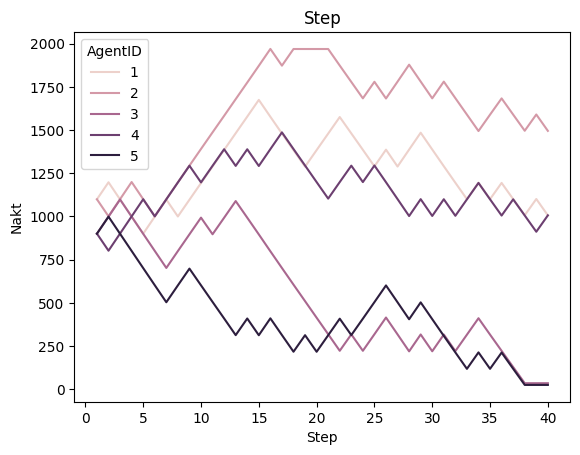

In [181]:
# Ajan verisini pandas DataFrame olarak al
agent_df = model.datacollector.get_agent_vars_dataframe()

# Check data types and convert if necessary
# For example, if "Nakit" column is not numeric, convert it to numeric
agent_df["Nakit"] = pd.to_numeric(agent_df["Nakit"])

gr = sns.lineplot(data=agent_df, x="Step", y="Nakit", hue="AgentID") # Specify x and y
gr.set(title="Step", ylabel="Nakt");

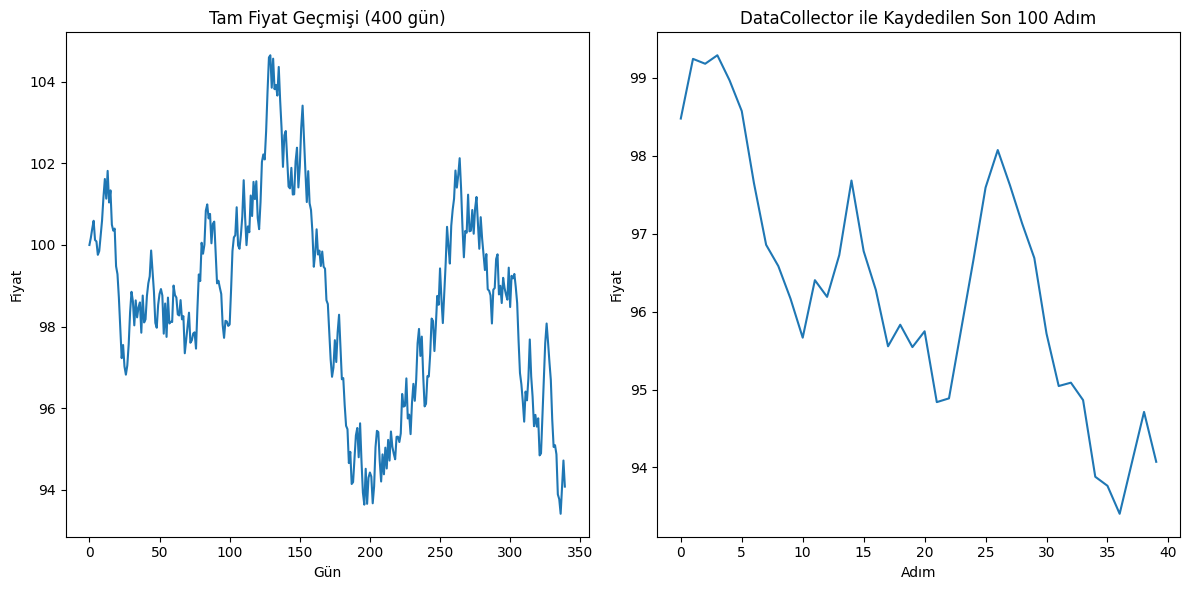

In [182]:
# Extract MoneyModel data in a Pandas dataframe
model_data = model.datacollector.get_model_vars_dataframe()

# Grafik çiz
plt.figure(figsize=(12, 6))

# 1. Tüm price_history'nin grafiği
plt.subplot(1, 2, 1)
all_prices = model.price_history
plt.plot(all_prices, label='Tüm Fiyat Geçmişi')
plt.title("Tam Fiyat Geçmişi (400 gün)")
plt.xlabel("Gün")
plt.ylabel("Fiyat")

# 2. DataCollector ile kaydedilen son 100 adımın grafiği
plt.subplot(1, 2, 2)
last_100_prices = model_data["Price"].tail(100)
last_100_prices.plot(label='Son 100 Adım')
plt.title("DataCollector ile Kaydedilen Son 100 Adım")
plt.xlabel("Adım")
plt.ylabel("Fiyat")

plt.tight_layout()
plt.show()